In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [5]:
# Step 2: Load datasets
air = pd.read_csv('airquality.csv')
print(air)
heart = pd.read_csv('heart.csv')
print(heart)

     Unnamed: 0  Ozone  Solar.R  Wind  Temp  Month  Day
0             1   41.0    190.0   7.4    67      5    1
1             2   36.0    118.0   8.0    72      5    2
2             3   12.0    149.0  12.6    74      5    3
3             4   18.0    313.0  11.5    62      5    4
4             5    NaN      NaN  14.3    56      5    5
..          ...    ...      ...   ...   ...    ...  ...
148         149   30.0    193.0   6.9    70      9   26
149         150    NaN    145.0  13.2    77      9   27
150         151   14.0    191.0  14.3    75      9   28
151         152   18.0    131.0   8.0    76      9   29
152         153   20.0    223.0  11.5    68      9   30

[153 rows x 7 columns]
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   


In [6]:
# Step 3: Data Cleaning (fill and drop missing values)
air = air.ffill().dropna()
heart = heart.ffill().dropna()

In [7]:
# Step 4: Data Integration (join both using ID)
air['ID'] = range(len(air))
heart['ID'] = range(len(heart))
merged = pd.merge(air, heart, on='ID')
print("Merged dataset size:", merged.shape)

Merged dataset size: (153, 22)


In [8]:
# Step 5: Data Transformation (normalize air columns)
cols = ['Ozone', 'Solar.R', 'Wind', 'Temp']
cols = [c for c in cols if c in air.columns]
scaled = pd.DataFrame(MinMaxScaler().fit_transform(air[cols]), columns=cols)
print("\nNormalized Air Data:\n", scaled.head(2))


Normalized Air Data:
       Ozone   Solar.R      Wind      Temp
0  0.239521  0.559633  0.300000  0.268293
1  0.209581  0.339450  0.331579  0.390244


In [9]:
# Step 6: Error Correction (remove Ozone outliers)
ozone_mean = air['Ozone'].mean()
ozone_std = air['Ozone'].std()
air['Ozone'] = np.where(abs(air['Ozone'] - ozone_mean) > 3*ozone_std, ozone_mean, air['Ozone'])


📊 Linear Regression:
R²: 0.31362039047955603
MAE: 5.225228766056548
MSE: 45.029645017508756


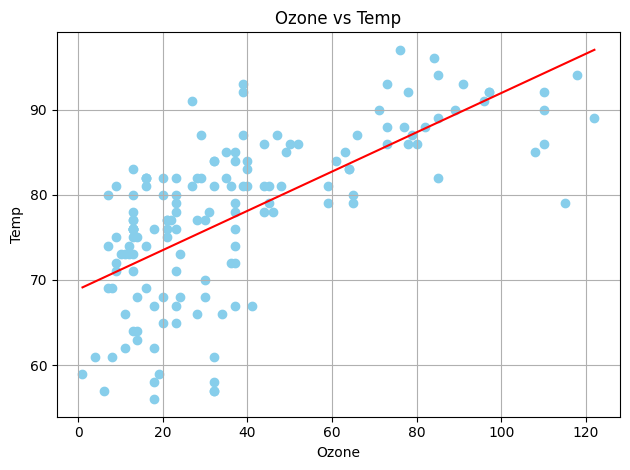

In [10]:
# Step 7: Linear Regression (Temp ~ Ozone)
air = air.dropna(subset=['Ozone', 'Temp'])
X, y = air[['Ozone']], air['Temp']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

print("\n📊 Linear Regression:")
print("R²:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

# Plot
plt.scatter(X, y, color='skyblue')
plt.plot(X.sort_values('Ozone'), model.predict(X.sort_values('Ozone')), color='red')
plt.xlabel('Ozone'); plt.ylabel('Temp'); plt.title('Ozone vs Temp')
plt.grid(); plt.tight_layout(); plt.show()